## Emergency Vehicle Identification CNN

### Project Overview
This project focuses on developing a Convolutional Neural Network (CNN) to classify images of vehicles as either **emergency** or **non-emergency**. The goal is to build a robust model suitable for real-world deployment by experimenting with different architectures, regularisation techniques, and hyperparameters.

The dataset is sourced from Kaggle and contains labelled images used to train and evaluate the model.


In [2]:
# Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

### Loading Dataset
The dataset labels are loaded from a CSV file, which maps each image to its corresponding class:
- **1 = Emergency vehicle**
- **0 = Non-emergency vehicle**

In [3]:
#  Load labels from train CSV (Ground truth)
labels_df = pd.read_csv("train.csv")

# Verify labels
print(labels_df["emergency_or_not"].value_counts())
# 1 = Emergency, 0 = Non‑Emergency

emergency_or_not
0    965
1    681
Name: count, dtype: int64


### Train-Validation Split
The dataset is split into training and validation sets. This ensures that both classes (emergency and non-emergency) are proportionally represented in each subset.

Training set: 80%
Validation set: 20%


In [4]:
# Train / Validation split
train_df, val_df = train_test_split(
    labels_df,
    test_size=0.2,
    stratify=labels_df["emergency_or_not"],
    random_state=42 )

### Image Preprocessing
All images are resized to **128 × 128 pixels** to ensure a consistent input size for the CNN.
The images are then converted into NumPy arrays for model input.

In [5]:
#  Image loader function
def load_images(df, base_dir, img_size=(128, 128)):
    X, y = [], []

    for _, row in df.iterrows():
        # images are in Emergency_Vehicles/train/
        img_path = os.path.join(base_dir, "train", row["image_names"])

        if not os.path.exists(img_path):
            raise FileNotFoundError(img_path)

        img = load_img(img_path, target_size=img_size)
        img = img_to_array(img) / 255.0

        X.append(img)
        y.append(row["emergency_or_not"])

    return np.array(X), np.array(y)

In [6]:
#  Load datasets
IMAGE_DIR = "Emergency_Vehicles"

x_train, y_train = load_images(train_df, IMAGE_DIR)
x_val, y_val = load_images(val_df, IMAGE_DIR)

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)

(1316, 128, 128, 3) (1316,)
(330, 128, 128, 3) (330,)


### Data Visualisation
A sample image from the training set is displayed to verify correct label assignment and proper preprocessing.

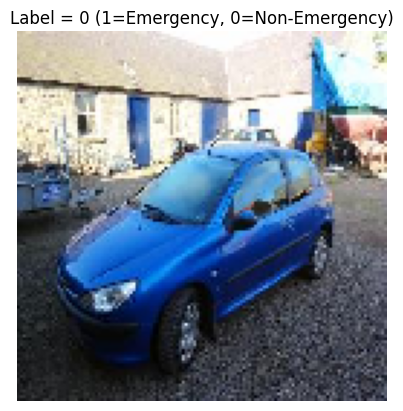

In [12]:
# Visual Verification
plt.imshow(x_train[1])
plt.title(f"Label = {y_train[1]} (1=Emergency, 0=Non‑Emergency)")
plt.axis("off")
plt.show()

### Baseline CNN Architecture
The baseline model is composed of three convolutional blocks, beginning with 32-filter Conv2D layer, each followed by max pooling. The model is trained for **20 epochs** using the default Adam optimiser (0.001)

Key components:
- Conv2D layers with ReLU activation
- MaxPooling layers for dimensionality reduction
- Fully connected Dense layer for classification
- Softmax output layer for binary classification

In [14]:
# Baseline CNN Model
# Creating a Sequential class instance of the model with 3 convulation blocks.
# Including model parameters such as Pooling layer, flatten layer, dense layer and output dense layer. 
baseline_cnn = Sequential([ Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
                     MaxPooling2D(2,2), 
                     Conv2D(64, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
                     MaxPooling2D(2,2),
                     Conv2D(128, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
                     MaxPooling2D(2,2),
                     Flatten(), Dense(64, activation="relu"),
                     Dense(2, activation="softmax") ])

# Here i compile the CNN model using the default Adam optimiser learning rate.
# loss function: sparse_categorical_crossentropy, perfomance metric: accuracy
baseline_cnn.compile( optimizer=Adam(), loss="sparse_categorical_crossentropy",
    metrics=["accuracy"] )

baseline_cnn.summary()

# Model Training (20 Epochs)
history_1 = baseline_cnn.fit( x_train, y_train, epochs=20, batch_size=32, validation_data=(x_val, y_val) )

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,190,594 (8.36 MB)

 Trainable params: 2,190,594 (8.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - accuracy: 0.5731 - loss: 0.8873 - val_accuracy: 0.5879 - val_loss: 0.6626
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - accuracy: 0.6942 - loss: 0.5680 - val_accuracy: 0.7485 - val_loss: 0.4898
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - accuracy: 0.7866 - loss: 0.4536 - val_accuracy: 0.7788 - val_loss: 0.4631
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - accuracy: 0.8287 - loss: 0.4100 - val_accuracy: 0.7758 - val_loss: 0.4645
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - accuracy: 0.8544 - loss: 0.3432 - val_accuracy: 0.7818 - val_loss: 0.4497
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - accuracy: 0.8985 - loss: 0.2596 - val_accuracy: 0.7636 - val_loss: 0.4604
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - accuracy: 0.9071 - loss: 0.2246 - val_accuracy: 0.7697 - val_loss: 0.5627
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - accuracy: 0.9191 - loss: 0.1987 - val_accuracy: 

### Model Evaluation
The model is evaluated using the following metrics:
- Accuracy: Overall correctness of predictions
- Precision: Proportion of predicted emergency vehicles that are correct
- Recall: Ability to correctly identify emergency vehicles

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


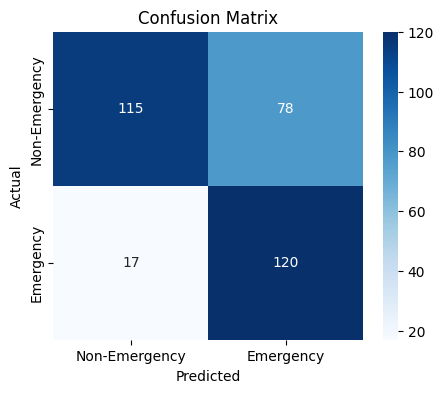

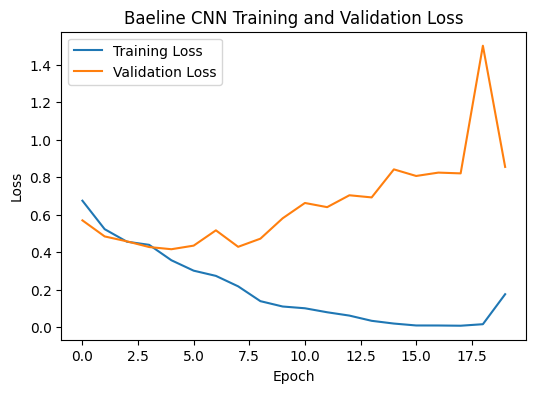

Baseline CNN Performance Table:


,Metric,Baseline CNN
0,Accuracy,0.712121
1,Precision,0.606061
2,Recall,0.875912


In [19]:
# Model Evaluation 

# Performance Metrics (accuracy, precision, recall)
y_pred_1 = np.argmax(baseline_cnn.predict(x_val), axis=1)

accuracy = accuracy_score(y_val, y_pred_1)
precision = precision_score(y_val, y_pred_1)
recall = recall_score(y_val, y_pred_1)

# Confusion Matrix & Loss Curves
cm = confusion_matrix(y_val, y_pred_1)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non‑Emergency", "Emergency"],
            yticklabels=["Non‑Emergency", "Emergency"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history_1.history["loss"], label="Training Loss")
plt.plot(history_1.history["val_loss"], label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baeline CNN Training and Validation Loss")
plt.show()

# Model Evaluation 
results_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall"],
    "Baseline CNN": [accuracy, precision, recall]
})
print("Baseline CNN Performance Table:")
results_table

The baseline CNN achieved an accuracy of 71.2%, with a high recall of 87.6% but relatively low precision of 60.6%. This indicates that the model is effective at identifying emergency vehicles but tends to misclassify a significant number of non-emergency vehicles as emergency vehicles.

The confusion matrix further confirms this behaviour, showing a high number of false positives (78), alongside a relatively small number of false negatives (17). This suggests that the model is biased toward predicting the emergency class, prioritising recall over precision.

Analysis of the training and validation loss curves reveals clear signs of overfitting. While training loss decreases steadily, validation loss increases sharply after several epochs, indicating that the model fails to generalise well to unseen data. Overall, although the model performs reasonably well in detecting emergency vehicles, its high false positive rate and overfitting limit its effectiveness for real-world deployment. This highlights the need for improved regularisation and hyperparameter tuning.

## Hyperparameter Tuning
To improve model performance in a scientifically rigorous manner, a structured hyperparameter tuning strategy was adopted. Rather than modifying multiple parameters simultaneously, a controlled-variable approach was used, where one key factor is changed at a time while keeping all others constant. This ensures that any observed performance differences can be directly attributed to the specific modification.
### Experimental Tuning Strategy
The tuning process followed this order:

1. Baseline Model
Establish a benchmark performance for comparison.

2. Regularisation (Dropout)
Introduce dropout to reduce overfitting.

3. Learning Rate Tuning
Adjust optimisation dynamics to improve convergence.

4. Batch Size Tuning
Analyse impact on training stability and generalisation.

5. Architecture Depth
Increase model capacity once optimisation is stable.

### Model 1: Baseline CNN
The baseline model was implemented using three convolutional blocks and trained using the default Adam optimiser (learning rate = 0.001) to establish a reference point for all subsequent experiments and identify initial issues such as overfitting or class imbalance
### Model 2: Custom CNN A (Add Dropout)
A dropout layer (rate = 0.5) was added after the dense layer to reduce overfitting observed in the baseline model and improve generalisation to unseen data. Dropout is a widely used regularisation technique that prevents co-adaptation of neurons and reduces overfitting in deep networks (Srivastava et al., 2014).

### Model 3: Custom CNN B (Tune Learning Rate)
The learning rate was reduced from 0.001 to 0.0001. This is to improve convergence stability and prevent overshooting during optimisation. The learning rate is one of the most critical hyperparameters influencing model convergence and performance (Goodfellow, Bengio and Courville, 2016).

### Model 4: Custom CNN C (Tune Batch Size)
The batch size was increased from 32 to 64 to evaluate its impact on training stability and analyse its effect on model generalisation. Prior Literature suggests that mini-batch sizes in the range of 32-128 are commonly effective for deep learning optimization. Smaller batches introduce noise that can improve generalisation, while larger batches can lead to faster but potentially less generalisable convergence (Keskar et al., 2017). A batch size of 64 was selected as it represents a moderate increase from baseline, allowing smoother gradient updates.

### Model 5: Custom CNN D (Increase Architecture Depth)
An additional convolutional block (Conv2D + MaxPooling) was introduced to increase model depth. To improve feature extraction capability and enhance model capacity for complex patterns. Deeper convolutional networks are capable of learning hierarchical representations of visual features, leading to improved performance on image classification tasks (Krizhevsky, Sutskever and Hinton, 2012).

### Custom CNN A. Add Dropout

C:\Program Files\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,190,594 (8.36 MB)

 Trainable params: 2,190,594 (8.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - accuracy: 0.5282 - loss: 0.7357 - val_accuracy: 0.7152 - val_loss: 0.5809
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.7309 - loss: 0.5536 - val_accuracy: 0.7455 - val_loss: 0.5201
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - accuracy: 0.7577 - loss: 0.5119 - val_accuracy: 0.7636 - val_loss: 0.4573
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - accuracy: 0.8003 - loss: 0.4500 - val_accuracy: 0.7788 - val_loss: 0.4561
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - accuracy: 0.8211 - loss: 0.4129 - val_accuracy: 0.8152 - val_loss: 0.4191
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.8583 - loss: 0.3411 - val_accuracy: 0.8212 - val_loss: 0.3910
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.8618 - loss: 0.3241 - val_accuracy: 0.8212 - val_loss: 0.4353
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.8867 - loss: 0.2883 - val_accuracy

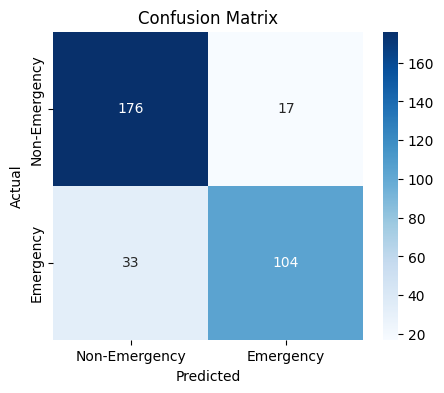

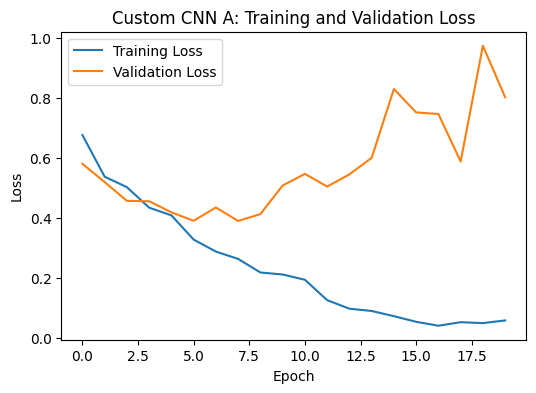

Custom CNN A Performance Table:


,Metric,Custom CNN A
0,Accuracy,0.848485
1,Precision,0.859504
2,Recall,0.759124


In [20]:
# Custom CNN A. Adding a 50% Dropout rate as regularization to test whether overfitting reduces.

custom_cnn_a = Sequential([ Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
                     MaxPooling2D(2,2), 
                     Conv2D(64, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
                     MaxPooling2D(2,2),
                     Conv2D(128, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
                     MaxPooling2D(2,2),
                     Flatten(), Dense(64, activation="relu"), Dropout(0.5),
                     Dense(2, activation="softmax") ])

custom_cnn_a.compile( optimizer=Adam(), loss="sparse_categorical_crossentropy",
    metrics=["accuracy"] )

custom_cnn_a.summary()

#Training
history_2 = custom_cnn_a.fit( x_train, y_train, epochs=20, batch_size=32, validation_data=(x_val, y_val) )

# Model Evaluation 
y_pred_2 = np.argmax(custom_cnn_a.predict(x_val), axis=1)

accuracy = accuracy_score(y_val, y_pred_2)
precision = precision_score(y_val, y_pred_2)
recall = recall_score(y_val, y_pred_2)

# Confusion Matrix & Loss Curves
cm = confusion_matrix(y_val, y_pred_2)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non‑Emergency", "Emergency"],
            yticklabels=["Non‑Emergency", "Emergency"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history_2.history["loss"], label="Training Loss")
plt.plot(history_2.history["val_loss"], label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN A: Training and Validation Loss")
plt.show()

# Model Evaluation 
results_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall"],
    "Custom CNN A": [accuracy, precision, recall]
})
print("Custom CNN A Performance Table:")
results_table

The introduction of dropout (rate = 0.5) significantly improved the performance and generalisation capability of the model compared to the baseline CNN.

The model achieved an accuracy of **84.85%**, demonstrating a substantial improvement in overall classification performance. Precision increased to **85.95%**, indicating that the model is highly reliable when predicting emergency vehicles, with a strong reduction in false positives. Recall reached **75.91%**, showing that the model still identifies most emergency vehicles, although some are missed.

Analysis of the confusion matrix provides deeper insight into model behaviour. The model correctly classified **176 non-emergency vehicles (true negatives)** and **104 emergency vehicles (true positives)**. Importantly, false positives were reduced to **17**, confirming that the model is less likely to incorrectly label non-emergency vehicles as emergency vehicles. However, **33 false negatives** indicate that some emergency vehicles are not detected, reflecting a trade-off between precision and recall. Compared to the baseline model, this represents a shift toward a more conservative and balanced prediction strategy.

The loss curves reveal that training loss steadily decreases, indicating effective learning. However, validation loss initially decreases and then begins to increase after approximately 6–8 epochs. This suggests that, although dropout reduces overfitting, it does not completely eliminate it. The widening gap between training and validation loss confirms that the model still begins to memorise the training data at later stages.

### Custom CNN B. Tune Learning Rate

C:\Program Files\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,190,594 (8.36 MB)

 Trainable params: 2,190,594 (8.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.5814 - loss: 0.6753 - val_accuracy: 0.6364 - val_loss: 0.6249
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - accuracy: 0.6825 - loss: 0.5994 - val_accuracy: 0.7545 - val_loss: 0.5387
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step - accuracy: 0.7363 - loss: 0.5423 - val_accuracy: 0.7576 - val_loss: 0.5204
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - accuracy: 0.7525 - loss: 0.5049 - val_accuracy: 0.7636 - val_loss: 0.4972
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - accuracy: 0.7663 - loss: 0.4864 - val_accuracy: 0.7667 - val_loss: 0.4775
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - accuracy: 0.8113 - loss: 0.4414 - val_accuracy: 0.7545 - val_loss: 0.4773
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 144ms/step - accuracy: 0.7853 - loss: 0.4564 - val_accuracy: 0.7788 - val_loss: 0.4659
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - accuracy: 0.8314 - loss: 0.4095 - val_accura

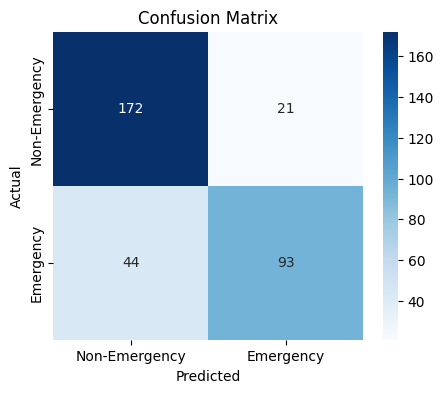

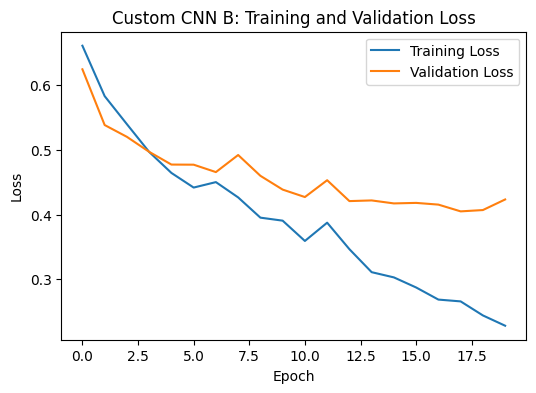

Custom CNN B Performance Table:


,Metric,Custom CNN B
0,Accuracy,0.803030
1,Precision,0.815789
2,Recall,0.678832


In [22]:
# Custom CNN B
custom_cnn_b = Sequential([ Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
                     MaxPooling2D(2,2), 
                     Conv2D(64, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
                     MaxPooling2D(2,2), 
                     Conv2D(128, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
                     MaxPooling2D(2,2), 
                     Flatten(), Dense(64, activation="relu"), Dropout(0.5),
                     Dense(2, activation="softmax") ])

# Tuning learning rate to 0.0001 to improve convergence stability
custom_cnn_b.compile( optimizer=Adam(learning_rate=0.0001), loss="sparse_categorical_crossentropy",
    metrics=["accuracy"] )

custom_cnn_b.summary()

# Training
history_3 = custom_cnn_b.fit( x_train, y_train, epochs=20, batch_size=32, validation_data=(x_val, y_val) )

# Performance Metrics
y_pred_3 = np.argmax(custom_cnn_b.predict(x_val), axis=1)

accuracy = accuracy_score(y_val, y_pred_3)
precision = precision_score(y_val, y_pred_3)
recall = recall_score(y_val, y_pred_3)

# Confusion Matrix & Loss Curves
cm = confusion_matrix(y_val, y_pred_3)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non‑Emergency", "Emergency"],
            yticklabels=["Non‑Emergency", "Emergency"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history_3.history["loss"], label="Training Loss")
plt.plot(history_3.history["val_loss"], label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN B: Training and Validation Loss")
plt.show()

# Model Evaluation 
results_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall"],
    "Custom CNN B": [accuracy, precision, recall]
})
print("Custom CNN B Performance Table:")
results_table

### Custom CNN B 

Custom CNN B introduced a reduced learning rate (0.0001) while retaining dropout regularisation, with the aim of improving convergence stability and overall model performance.

The model achieved an accuracy of **80.30%**, which represents a decline compared to Custom CNN A. Precision remained relatively strong at **81.58%**, indicating that predictions of emergency vehicles are still fairly reliable. However, recall dropped to **67.88%**, showing that the model is less effective at identifying emergency vehicles and misses a larger proportion of true cases.

The confusion matrix provides further insight into this behaviour. The model correctly classified **172 non-emergency vehicles (true negatives)** and **93 emergency vehicles (true positives)**. However, **21 false positives** indicate a slight increase in incorrect emergency predictions compared to Custom CNN A. More notably, **44 false negatives** highlight a substantial drop in the model’s ability to detect emergency vehicles. This confirms that the lower recall is driven by an increased number of missed emergency cases.

Analysis of the loss curves indicates improved training stability compared to the previous model. Both training and validation loss decrease smoothly, and the gap between them remains relatively small throughout the training process. Unlike Custom CNN A, there is no sharp divergence between training and validation loss, suggesting that the reduced learning rate helps control overfitting and leads to more stable convergence.

Overall, Custom CNN B demonstrates improved optimisation behaviour and reduced overfitting due to the lower learning rate. However, this comes at the cost of reduced performance, particularly in recall.

### Custom CNN C. Tune Batch Size

C:\Program Files\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │       1,048,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,437,186 (5.48 MB)

 Trainable params: 1,437,186 (5.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 336ms/step - accuracy: 0.5953 - loss: 0.6797 - val_accuracy: 0.5848 - val_loss: 0.6607
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 342ms/step - accuracy: 0.5963 - loss: 0.6508 - val_accuracy: 0.5909 - val_loss: 0.6316
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 337ms/step - accuracy: 0.6649 - loss: 0.6093 - val_accuracy: 0.6758 - val_loss: 0.5853
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 326ms/step - accuracy: 0.7351 - loss: 0.5614 - val_accuracy: 0.7152 - val_loss: 0.5535
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 331ms/step - accuracy: 0.7333 - loss: 0.5354 - val_accuracy: 0.6818 - val_loss: 0.5771
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 338ms/step - accuracy: 0.7426 - loss: 0.5543 - val_accuracy: 0.7455 - val_loss: 0.5157
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 327ms/step - accuracy: 0.7581 - loss: 0.5042 - val_accuracy: 0.7667 - val_loss: 0.4979
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 328ms/step - accuracy: 0.7589 - loss: 0.4891 - val_accuracy

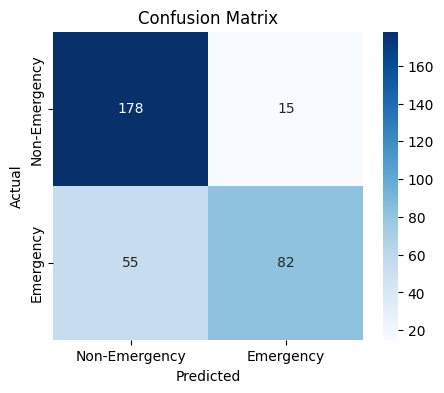

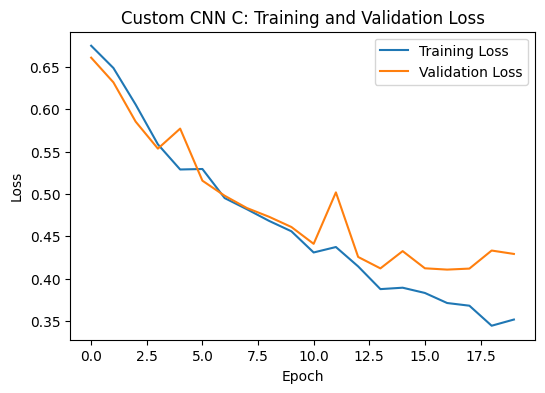

Custom CNN C Performance Table:


,Metric,Custom CNN C
0,Accuracy,0.787879
1,Precision,0.845361
2,Recall,0.598540


In [23]:
# Custom CNN C
custom_cnn_c = Sequential([ Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
                     MaxPooling2D(2,2), 
                     Conv2D(64, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
                     MaxPooling2D(2,2), 
                     Conv2D(128, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
                     MaxPooling2D(2,2),
                     Conv2D(256, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
                     MaxPooling2D(2,2), 
                     Flatten(), Dense(64, activation="relu"), Dropout(0.5),
                     Dense(2, activation="softmax") ])

custom_cnn_c.compile( optimizer=Adam(learning_rate=0.0001), loss="sparse_categorical_crossentropy",
    metrics=["accuracy"] )

custom_cnn_c.summary()

# Training. Tune Batch Size to 64 to investigate smoother gradient updates and test generalization to unseen data.
history_4 = custom_cnn_c.fit( x_train, y_train, epochs=20, batch_size=64, validation_data=(x_val, y_val) )

# Performance Metrics
y_pred_4 = np.argmax(custom_cnn_c.predict(x_val), axis=1)

accuracy = accuracy_score(y_val, y_pred_4)
precision = precision_score(y_val, y_pred_4)
recall = recall_score(y_val, y_pred_4)

# Confusion Matrix & Loss Curves
cm = confusion_matrix(y_val, y_pred_4)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non‑Emergency", "Emergency"],
            yticklabels=["Non‑Emergency", "Emergency"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history_4.history["loss"], label="Training Loss")
plt.plot(history_4.history["val_loss"], label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN C: Training and Validation Loss")
plt.show()

# Model Evaluation 
results_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall"],
    "Custom CNN C": [accuracy, precision, recall]
})
print("Custom CNN C Performance Table:")
results_table

### Custom CNN C

Custom CNN C introduced a larger batch size (64) along with increased model capacity by adding an additional convolutional layer, while retaining the reduced learning rate and dropout regularisation. The aim was to evaluate the impact of batch size on training stability and generalisation performance.

The model achieved an accuracy of **78.79%**, representing a further decline compared to Custom CNN B. Precision increased slightly to **84.54%**, indicating that predictions of emergency vehicles remain highly reliable, with a low rate of false positives. However, recall dropped significantly to **59.85%**, highlighting a substantial decrease in the model’s ability to correctly identify emergency vehicles.

The confusion matrix provides deeper insight into this performance. The model correctly classified **178 non-emergency vehicles (true negatives)** and **82 emergency vehicles (true positives)**. False positives were reduced to **15**, the lowest among all models so far, demonstrating very strong precision and conservative prediction behaviour. However, **55 false negatives** represent a significant increase, indicating that many emergency vehicles are missed. This confirms that the model has become overly conservative, prioritising precision at the expense of recall.

Analysis of the loss curves shows relatively stable training and validation behaviour. Both training and validation loss decrease consistently over time, and the gap between them remains moderate, suggesting improved control over overfitting compared to earlier models. The absence of sharp divergence indicates that the combination of a lower learning rate and larger batch size contributes to smoother optimisation.

### Custom CNN D. Increase Architecture Depth

C:\Program Files\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)                   │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_20 (MaxPooling2D)      │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_21 (Conv2D)                   │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_21 (MaxPooling2D)      │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_22 (Conv2D)                   │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_22 (MaxPooling2D)      │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_23 (Conv2D)                   │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_23 (MaxPooling2D)      │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │       1,048,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,437,186 (5.48 MB)

 Trainable params: 1,437,186 (5.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 340ms/step - accuracy: 0.5687 - loss: 0.6837 - val_accuracy: 0.5848 - val_loss: 0.6647
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 331ms/step - accuracy: 0.6018 - loss: 0.6600 - val_accuracy: 0.6909 - val_loss: 0.6257
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 337ms/step - accuracy: 0.6673 - loss: 0.6207 - val_accuracy: 0.7061 - val_loss: 0.5784
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 341ms/step - accuracy: 0.7145 - loss: 0.5585 - val_accuracy: 0.7485 - val_loss: 0.5335
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 345ms/step - accuracy: 0.7288 - loss: 0.5334 - val_accuracy: 0.7667 - val_loss: 0.5008
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 338ms/step - accuracy: 0.7689 - loss: 0.5104 - val_accuracy: 0.7667 - val_loss: 0.4958
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 333ms/step - accuracy: 0.7728 - loss: 0.4790 - val_accuracy: 0.7515 - val_loss: 0.5065
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 332ms/step - accuracy: 0.7848 - loss: 0.4623 - val_accura

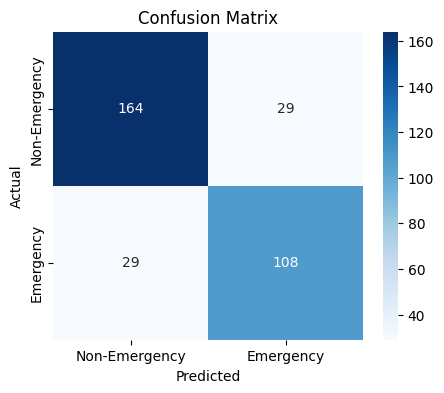

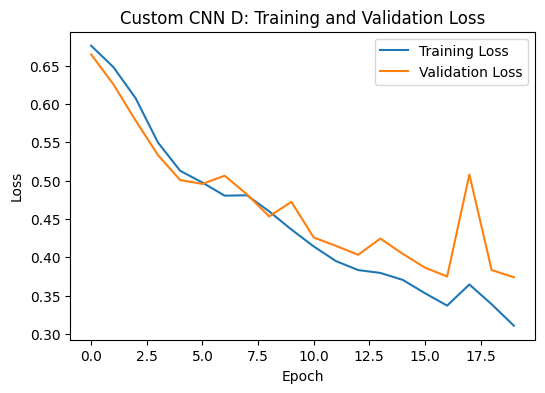

Custom CNN D Performance Table:


,Metric,Custom CNN D
0,Accuracy,0.824242
1,Precision,0.788321
2,Recall,0.788321


In [26]:
# Custom CNN D. 4th Convulation Block introduced to increase model depth and feature extraction capacity

custom_cnn_d = Sequential([ Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
                     MaxPooling2D(2,2), 
                     Conv2D(64, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
                     MaxPooling2D(2,2), 
                       Conv2D(128, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
                     MaxPooling2D(2,2),
                     Conv2D(256, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
                     MaxPooling2D(2,2),
                     Flatten(), Dense(64, activation="relu"), Dropout(0.5),
                     Dense(2, activation="softmax") ])

custom_cnn_d.compile( optimizer=Adam(learning_rate=0.0001), loss="sparse_categorical_crossentropy",
    metrics=["accuracy"] )

custom_cnn_d.summary()

# Training
history_5 = custom_cnn_d.fit( x_train, y_train, epochs=20, batch_size=64, validation_data=(x_val, y_val) )

# Performance Metrics
y_pred_5 = np.argmax(custom_cnn_d.predict(x_val), axis=1)

accuracy = accuracy_score(y_val, y_pred_5)
precision = precision_score(y_val, y_pred_5)
recall = recall_score(y_val, y_pred_5)

# Confusion Matrix & Loss Curves
cm = confusion_matrix(y_val, y_pred_5)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non‑Emergency", "Emergency"],
            yticklabels=["Non‑Emergency", "Emergency"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history_5.history["loss"], label="Training Loss")
plt.plot(history_5.history["val_loss"], label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN D: Training and Validation Loss")
plt.show()

# Model Evaluation 
results_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall"],
    "Custom CNN D": [accuracy, precision, recall]
})
print("Custom CNN D Performance Table:")
results_table

### Custom CNN D 

Custom CNN D increased the architectural depth of the model by adding an additional convolutional block, while maintaining dropout regularisation, a reduced learning rate, and a larger batch size. The aim was to enhance feature extraction and improve classification performance by increasing model capacity.

The model achieved an accuracy of **82.42%**, representing an improvement over Custom CNN B and C, though slightly lower than Custom CNN A. Precision and recall are both **78.83%**, indicating a well-balanced model that performs equally well in correctly identifying emergency vehicles and avoiding misclassification. This balance suggests that the model has achieved a more effective trade-off between false positives and false negatives.

The confusion matrix supports this observation. The model correctly classified **164 non-emergency vehicles (true negatives)** and **108 emergency vehicles (true positives)**. There are **29 false positives** and **29 false negatives**, showing a symmetrical distribution of errors. Compared to previous models, Custom CNN D does not overly prioritise either precision or recall, making it a more balanced classifier overall. Although false positives are higher than in Custom CNN C, the reduction in false negatives represents a significant improvement in detecting emergency vehicles.

Analysis of the loss curves shows that both training and validation loss decrease steadily, indicating effective learning. The gap between training and validation loss remains moderate, although there is a noticeable fluctuation in validation loss at later epochs, suggesting some instability and mild overfitting. However, this behaviour is less severe than in the baseline model, indicating that regularisation and learning rate tuning are still effective in controlling overfitting to some extent.

Custom CNN D demonstrates a strong balance between precision and recall, making it a more reliable model for practical applications. While it does not achieve the highest accuracy, its balanced performance and improved detection of emergency vehicles make it a strong candidate compared to other models. This suggests that increasing model depth can enhance feature representation, but must be carefully combined with proper regularisation to maintain generalisation performance.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


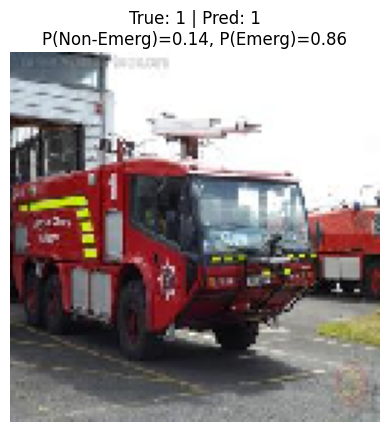

In [30]:
# Show Custom CNN D model confidence for random images
import random

idx = random.randint(0, len(x_val)-1)

probs = custom_cnn_d.predict(x_val[idx:idx+1])[0]
pred = np.argmax(probs)

plt.imshow(x_val[idx])
plt.title(
    f"True: {y_val[idx]} | Pred: {pred}\n"
    f"P(Non‑Emerg)={probs[0]:.2f}, P(Emerg)={probs[1]:.2f}"
)
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


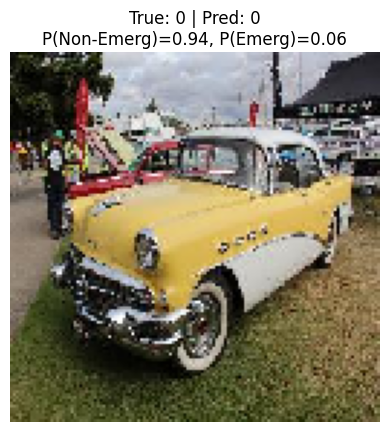

In [34]:
# Show model confidence for random images
import random

idx = random.randint(0, len(x_val)-1)

probs = custom_cnn_d.predict(x_val[idx:idx+1])[0]
pred = np.argmax(probs)

plt.imshow(x_val[idx])
plt.title(
    f"True: {y_val[idx]} | Pred: {pred}\n"
    f"P(Non‑Emerg)={probs[0]:.2f}, P(Emerg)={probs[1]:.2f}"
)
plt.axis("off")
plt.show()

### References

Bergstra, J. and Bengio, Y. (2012) ‘Random Search for Hyper-Parameter Optimization’, Journal of Machine Learning Research, 13, pp. 281–305.


Goodfellow, I., Bengio, Y. and Courville, A. (2016) Deep Learning. MIT Press.


Keskar, N.S. et al. (2017) ‘On Large-Batch Training for Deep Learning: Generalization Gap and Sharp Minima’, International Conference on Learning Representations (ICLR).


Krizhevsky, A., Sutskever, I. and Hinton, G.E. (2012) ‘ImageNet classification with deep convolutional neural networks’, Advances in Neural Information Processing Systems (NeurIPS).


Srivastava, N. et al. (2014) ‘Dropout: A Simple Way to Prevent Neural Networks from Overfitting’, Journal of Machine Learning Research, 15, pp. 1929–1958.